For plotting two specific groups from the output of Multiple_angles.py

In [56]:
import os
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import to_rgba
import seaborn as sns
import numpy as np
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
from scipy.stats import ks_2samp


In [84]:
#start with allangles_modified.csv
all_data = pd.read_csv("/Volumes/mohrlab/mohrlabspace/Nora_Mohr/ANALYSIS/Composite_Data/Angle_Dist/230711_240313_240827_240926_allangles_modified.csv")
identifier_str = "230711_240313_240827_240926"
output_dir = "/Volumes/mohrlab/mohrlabspace/Nora_Mohr/ANALYSIS/Composite_Data/Angle_Dist"

/var/folders/tn/mq6hmrjj03j8dxy2x5lk_1qw0000gn/T/ipykernel_2991/1623557832.py:2: DtypeWarning: Columns (5,6,63441,63442) have mixed types. Specify dtype option on import or set low_memory=False.
  all_data = pd.read_csv("/Volumes/mohrlab/mohrlabspace/Nora_Mohr/ANALYSIS/Composite_Data/Angle_Dist/230711_240313_240827_240926_allangles_modified.csv")


In [85]:
# Print available groups
unique_groups = all_data['group'].unique().tolist()
print("Unique groups found:", unique_groups)

Unique groups found: ['NHDF_hsv-1', 'NHDF_untreated', 'ICP4_dox', 'ICP4_none', 'NHDF-pLVX_dox', 'NHDF-pLVX_untreated', 'NHDF_HSV-1', 'NHDF_uninfected', 'ICP8_dox', 'NHDF-n208_dox', 'NHDF-n6_dox', 'HeLa-ICP4_dox', 'ICP8_none', 'NHDF-n6_untreated', 'HeLa-ICP4_untreated', 'RR-LL_dox', 'RR-LL_none']


In [ ]:
# === USER: Select any two groups from those printed above ===
selected_groups = ['ICP4_dox', 'ICP4_none']  # groups to plot
colors = ['#7F32BD', '#000000']  # your hex colors for each group

In [87]:
# Path to the angle distributions CSV
angle_csv = os.path.join(output_dir, f"{identifier_str}_angle_distributions.csv")

# Parameters
min_pts = 9
max_ss = 1
bin_size = 0.05

# --- Load or create data ---
if os.path.exists(angle_csv):
    print(f"Found existing angle distributions CSV. Loading: {angle_csv}")
    new_df = pd.read_csv(angle_csv)
else:
    print("No angle CSV found — generating distributions...")
    copy_all = all_data.copy()
    copy_all = copy_all[copy_all['group'].isin(selected_groups)]
    copy_all = copy_all.replace('', np.NaN)
    copy_all.dropna(axis=0, subset=['group'], inplace=True)

    start_pos = copy_all.columns.get_loc("0")
    stop_pos = len(copy_all.columns) - start_pos - 1

    data_arr = []
    for tlag in copy_all['tlag'].unique():
        for bin_left in np.arange(0, max_ss + bin_size, bin_size):
            data_arr.append([tlag, bin_left])
    new_df = pd.DataFrame(data_arr, columns=['tlag', 'bin'])

    for group in selected_groups:
        new_df[f"{group}-prop"] = 0
        new_df[f"{group}-count"] = 0
        new_df[f"{group}-total"] = 0
        for tlag in copy_all['tlag'].unique():
            cur_df = copy_all[(copy_all['group'] == group) & (copy_all['tlag'] == tlag)]
            obs_dist = pd.to_numeric(
                cur_df.iloc[:, start_pos:start_pos + stop_pos].values.flatten(),
                errors="coerce"
            )
            obs_dist = obs_dist[~np.isnan(obs_dist)]
            new_df.loc[(new_df['tlag'] == tlag), f"{group}-total"] = len(obs_dist)
            if len(obs_dist) > min_pts:
                n = len(obs_dist)
                counts, bins = np.histogram(obs_dist, bins=np.arange(0, max_ss + bin_size, bin_size))
                for i, val in enumerate(counts):
                    new_df.loc[(new_df['tlag'] == tlag) & (new_df['bin'] == bins[i]), f"{group}-prop"] = val / n
                    new_df.loc[(new_df['tlag'] == tlag) & (new_df['bin'] == bins[i]), f"{group}-count"] = val

    new_df.to_csv(angle_csv, index=False)
    print(f"Saved new CSV: {angle_csv}")


Found existing angle distributions CSV. Loading: /Volumes/mohrlab/mohrlabspace/Nora_Mohr/ANALYSIS/Composite_Data/Angle_Dist/230711_240313_240827_240926_angle_distributions.csv


Saved overlay plot: /Volumes/mohrlab/mohrlabspace/Nora_Mohr/ANALYSIS/Composite_Data/Angle_Dist/230711_240313_240827_240926_superimposed_plot_ICP4_dox-ICP4_none_angles.png


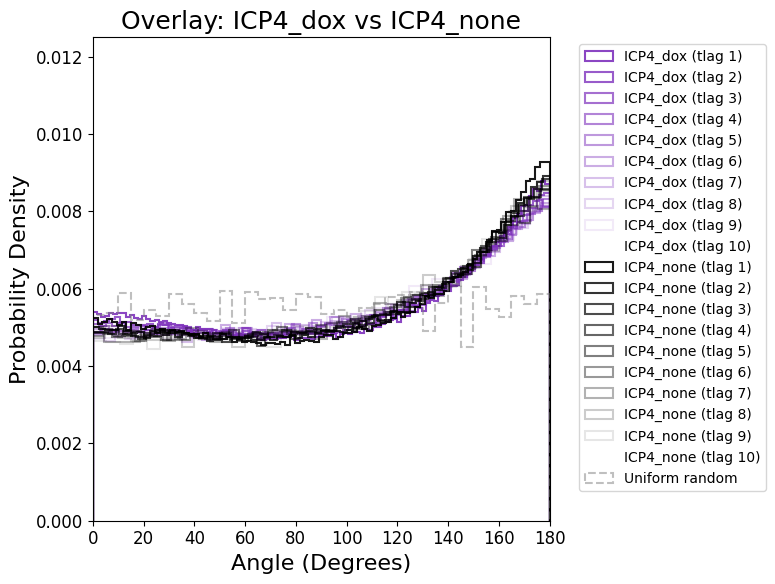

In [ ]:
# --- Plot overlaid groups ---
plt.rcParams['font.size'] = 12
plot_bins = np.arange(0, 181, 5)

fig, ax = plt.subplots(figsize=(8, 6))

alpha_min = 0.02
alpha_max = 1.0

for color, group in zip(colors, selected_groups):
    copy_all_group = all_data[all_data['group'] == group]
    copy_all_group = copy_all_group.replace('', np.NaN)
    copy_all_group.dropna(axis=0, subset=['group'], inplace=True)

    start_pos = copy_all_group.columns.get_loc("0")
    stop_pos = len(copy_all_group.columns) - start_pos - 1
    my_tlags = sorted(copy_all_group['tlag'].unique())  # <- SORTED
    n_tlags = len(my_tlags)

    # Precompute alphas for each tlag
    alphas = np.linspace(alpha_max, alpha_min, n_tlags)
    tlag_to_alpha = dict(zip(my_tlags, alphas))

    for tlag in my_tlags:
        cur_df = copy_all_group[copy_all_group['tlag'] == tlag]
        obs_dist = pd.to_numeric(cur_df.iloc[:, start_pos:start_pos + stop_pos].values.flatten(), errors='coerce')
        obs_dist = obs_dist[~np.isnan(obs_dist)]

        if len(obs_dist) > min_pts:
            plt.hist(
                obs_dist,
                bins='auto',
                alpha=tlag_to_alpha[tlag], # consistent alpha scaling
                label=f"{group} — tlag {tlag}",
                histtype='step',
                linewidth=1.5,
                color=color,
                density=True
            )

# Add random (uniform) reference
random_data = np.random.uniform(0, 180, size=10000)
plt.hist(
    random_data,
    bins=plot_bins,
    alpha=0.5,
    histtype='step',
    linewidth=1.5,
    linestyle='--',
    color='gray',
    density=True,
    label='Uniform random'
)

# Format plot
ax.set_title(f'Overlay: {selected_groups[0]} vs {selected_groups[1]}', fontsize=18)
ax.set_xlabel('Angle (Degrees)', fontsize=16)
ax.set_ylabel('Probability Density', fontsize=16)
ax.set_xlim(0, 180)
ax.set_ylim(0, 0.0125)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
outpath = f"{output_dir}/{identifier_str}_superimposed_plot_{selected_groups[0]}-{selected_groups[1]}_angles.png"
plt.savefig(outpath, bbox_inches='tight')
print(f"Saved overlay plot: {outpath}")
plt.show()

In [89]:
"""
Run KS test on angle distributions between selected groups at each tlag.
Generate volcano plot and save statistical results as CSV.
"""
# Extract group names from selected_groups
group1, group2 = selected_groups
print(f"Running KS tests for: {group1} vs {group2}")

# Prepare data
copy_all = all_data.copy()
copy_all = copy_all[copy_all['group'].isin(selected_groups)]
copy_all = copy_all.replace('', np.NaN)
copy_all.dropna(axis=0, subset=['group'], inplace=True)

# Identify columns
start_pos = copy_all.columns.get_loc("0")
stop_pos = len(copy_all.columns) - start_pos - 1
my_tlags = sorted(copy_all['tlag'].unique())

# Extract subsets
data_group1 = copy_all[copy_all['group'] == group1]
data_group2 = copy_all[copy_all['group'] == group2]

# Initialize storage
statistics = []
p_values = []

# Perform KS test per tlag
for tlag in my_tlags:
    obs_dist_group1 = np.asarray(
        data_group1[data_group1['tlag'] == tlag].iloc[:, start_pos:start_pos + stop_pos]
    ).flatten()
    obs_dist_group2 = np.asarray(
        data_group2[data_group2['tlag'] == tlag].iloc[:, start_pos:start_pos + stop_pos]
    ).flatten()

    # Convert to numeric and remove NaNs safely
    obs_dist_group1 = pd.to_numeric(pd.Series(obs_dist_group1), errors='coerce').dropna().to_numpy()
    obs_dist_group2 = pd.to_numeric(pd.Series(obs_dist_group2), errors='coerce').dropna().to_numpy()


    if len(obs_dist_group1) > 9 and len(obs_dist_group2) > 9:
        statistic, p_value = ks_2samp(obs_dist_group1, obs_dist_group2)
    else:
        statistic, p_value = np.nan, np.nan

    statistics.append(statistic)
    p_values.append(p_value)

# === Save results as CSV ===
results_df = pd.DataFrame({
    'tlag': my_tlags,
    'statistic': statistics,
    'p_value': p_values
})

csv_out = os.path.join(output_dir, f"{identifier_str}_KS-test_{group1}-{group2}.csv")
results_df.to_csv(csv_out, index=False)
print(f"KS test results saved: {csv_out}")


Running KS tests for: ICP4_dox vs ICP4_none
KS test results saved: /Volumes/mohrlab/mohrlabspace/Nora_Mohr/ANALYSIS/Composite_Data/Angle_Dist/230711_240313_240827_240926_KS-test_ICP4_dox-ICP4_none.csv


Volcano plot saved: /Volumes/mohrlab/mohrlabspace/Nora_Mohr/ANALYSIS/Composite_Data/Angle_Dist/230711_240313_240827_240926_KS-volcano_ICP4_dox-ICP4_none.png


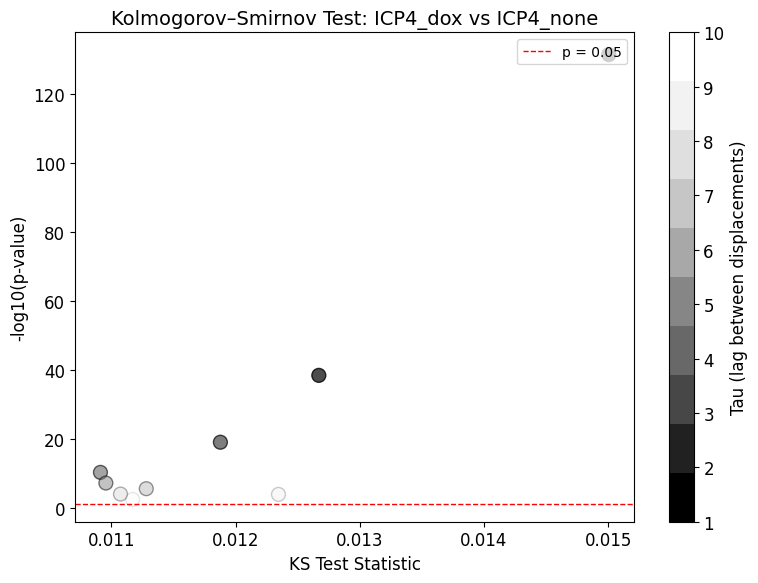

In [90]:

# === Volcano Plot ===
plt.figure(figsize=(8, 6))

# Create discrete grayscale colormap for tau
colors = plt.cm.Greys(np.linspace(0, 1, len(my_tlags)))[::-1]
cmap = ListedColormap(colors)

# Transparency scales inversely with tau
max_tau = max(my_tlags)
tau_transparency = [1 - (tau / max_tau) for tau in my_tlags]

# Scatter plot
scatter = plt.scatter(
    statistics,
    -np.log10(p_values),
    c=my_tlags,
    cmap=cmap,
    alpha=tau_transparency,
    vmin=min(my_tlags),
    vmax=max(my_tlags),
    s=100,
    edgecolor='black'
)

plt.title(f'Kolmogorov–Smirnov Test: {group1} vs {group2}', fontsize=14)
plt.xlabel('KS Test Statistic', fontsize=12)
plt.ylabel('-log10(p-value)', fontsize=12)
plt.axhline(-np.log10(0.05), color='red', linestyle='--', linewidth=1, label='p = 0.05')
plt.legend(loc='upper right', fontsize=10)
plt.grid(False)

# Add color bar for tau
cbar = plt.colorbar(scatter, ticks=my_tlags)
cbar.set_label('Tau (lag between displacements)', fontsize=12)
plt.tight_layout()

# Save volcano plot
plot_out = os.path.join(output_dir, f"{identifier_str}_KS-volcano_{group1}-{group2}.png")
plt.savefig(plot_out, bbox_inches='tight')
print(f"Volcano plot saved: {plot_out}")
plt.show()